# Arabic Sign Language Word-Level Detection (Frames + Temporal CNN)

This notebook processes folder-based frame sequences for Arabic Sign Language (ASL) words, extracts MediaPipe hand landmarks, caches them as temporal tensors, trains a temporal CNN classifier, and offers evaluation + inference utilities. Every line is commented so you can follow along.


In [1]:
# !pip install mediapipe opencv-python torch torchvision torchaudio pandas scikit-learn  # Uncomment inside Colab/venv if needed

In [28]:
import json  # Handles label map serialization
import os  # Enables basic filesystem checks
from collections import deque  # Supports rolling buffers for optional live inference
from dataclasses import dataclass  # Keeps configuration tidy
from pathlib import Path  # Simplifies cross-platform path operations
from typing import Dict, List, Tuple  # Provides descriptive type hints

import cv2  # Decodes image frames
import mediapipe as mp  # Supplies pretrained hand landmark detector
import numpy as np  # Powers vectorized math
import torch  # Hosts tensors and neural networks
from sklearn.model_selection import train_test_split  # Optional fallback splitting
from torch import nn  # Provides neural network layers
from torch.utils.data import DataLoader, Dataset  # Supplies dataset abstractions
import matplotlib.pyplot as plt  # Visualize training curves

In [29]:
@dataclass
class ARSLConfig:
    """Centralized configuration for dataset paths, preprocessing, and training hyperparameters."""

    dataset_root: Path = Path('/home/kaleab/Desktop/tiny-ArSL-dataset')  # Root containing train/val folders
    splits: Tuple[str, ...] = ('train', 'val')  # Expected split names inside dataset_root
    processed_dir: Path = Path('cache')  # Where cached numpy arrays will be stored
    sequence_length: int = 32  # Target number of frames per sign sequence
    num_hands: int = 2  # MediaPipe Hands tracks both hands separately
    num_keypoints: int = 21  # Hand landmarks output by MediaPipe
    landmark_dims: int = 3  # Each landmark has x,y,z coordinates
    min_detection_confidence: float = 0.7  # Probability threshold for detecting hands
    min_tracking_confidence: float = 0.7  # Tracking threshold to keep detections stable
    batch_size: int = 8  # Batch size for the DataLoaders
    num_epochs: int = 40  # Number of training epochs
    learning_rate: float = 1e-3  # Initial learning rate for Adam
    dropout: float = 0.3  # Dropout probability in the temporal CNN
    hidden_channels: Tuple[int, ...] = (128, 256)  # Temporal convolution channels
    kernel_size: int = 3  # Temporal convolution kernel width
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'  # Pick GPU when available

In [30]:
config = ARSLConfig()  # Instantiate configuration with defaults
config.processed_dir.mkdir(parents=True, exist_ok=True)  # Ensure cache directory exists before use
print(f'Using device: {config.device}')  # Confirm which accelerator will be used

mp_hands = mp.solutions.hands  # Keep a reference to MediaPipe Hands for reuse

Using device: cpu


In [31]:
def normalize_landmarks(landmarks: np.ndarray) -> np.ndarray:
    """Center and scale landmarks so absolute position/size differences vanish."""

    centered = landmarks - landmarks.mean(axis=0, keepdims=True)  # Center landmarks around the origin
    norm = np.linalg.norm(centered) + 1e-6  # Compute magnitude with epsilon to prevent division by zero
    normalized = centered / norm  # Scale to unit length for invariance
    return normalized  # Return normalized coordinates

In [32]:
def extract_hand_features(frame_rgb: np.ndarray, hands: mp.solutions.hands.Hands) -> np.ndarray:
    """Run MediaPipe Hands on one RGB frame and return flattened left/right features."""

    results = hands.process(frame_rgb)  # Execute landmark detection on the frame
    hand_tensor = np.zeros((config.num_hands, config.num_keypoints, config.landmark_dims), dtype=np.float32)  # Allocate storage for both hands
    if results.multi_hand_landmarks and results.multi_handedness:  # Only populate if any hands detected
        for landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):  # Iterate detections with handedness labels
            coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks.landmark], dtype=np.float32)  # Gather raw coordinates
            coords = normalize_landmarks(coords)  # Normalize per our helper
            label = handedness.classification[0].label.lower()  # Determine whether detection is left or right hand
            idx = 0 if label == 'left' else 1  # Convert handedness label to tensor index
            hand_tensor[idx] = coords  # Store normalized coordinates in the chosen slot
    flat = hand_tensor.reshape(-1)  # Flatten both hands into a single feature vector
    return flat  # Return the flattened representation

In [33]:
def load_instance_frames(instance_dir: Path) -> List[np.ndarray]:
    """Load all frames for one instance folder as RGB images sorted by filename."""

    frame_paths = sorted([p for p in instance_dir.glob('*') if p.is_file()])  # Collect and sort frame files
    if not frame_paths:  # Guard against empty instance folders
        raise RuntimeError(f'No frames found in {instance_dir}')  # Surface missing frames
    frames = []  # Accumulate decoded frames
    for path in frame_paths:  # Iterate each frame file
        image = cv2.imread(str(path))  # Decode the frame
        if image is None:  # Handle unreadable files
            raise RuntimeError(f'Failed to read frame {path}')  # Raise descriptive error
        frames.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert to RGB and store
    return frames  # Return RGB frame list

In [34]:
def resample_frames(frames: List[np.ndarray], target_length: int) -> List[np.ndarray]:
    """Uniformly resample frames to a fixed length by interpolation of indices."""

    indices = np.linspace(0, len(frames) - 1, target_length).astype(int)  # Pick evenly spaced indices
    sampled = [frames[i] for i in indices]  # Gather frames using sampled indices
    return sampled  # Return the resampled list

In [35]:
def instance_to_sequence(instance_dir: Path, hands: mp.solutions.hands.Hands) -> np.ndarray:
    """Convert one instance folder of frames into a (T x feature_dim) landmark tensor."""

    frames = load_instance_frames(instance_dir)  # Load all frames for this instance
    sampled_frames = resample_frames(frames, config.sequence_length)  # Resample to fixed length
    features = [extract_hand_features(frame, hands) for frame in sampled_frames]  # Convert each frame to hand features
    sequence = np.stack(features, axis=0).astype(np.float32)  # Stack features into a tensor
    return sequence  # Return the sequence ready for caching

In [36]:
def generate_split_cache(split: str, overwrite: bool = False) -> None:
    """Process one dataset split (train/val) into numpy caches."""

    split_dir = config.dataset_root / split  # Locate the split directory
    assert split_dir.exists(), f'Split folder missing: {split_dir}'  # Ensure split exists
    seq_path = config.processed_dir / f'{split}_sequences.npy'  # Target path for sequences
    label_path = config.processed_dir / f'{split}_labels.npy'  # Target path for integer labels
    map_path = config.processed_dir / 'label_map.json'  # Shared label map for all splits

    if seq_path.exists() and label_path.exists() and map_path.exists() and not overwrite:  # Reuse cache if present
        print(f'{split} cache already exists; set overwrite=True to rebuild.')  # Inform user about reuse
        return  # Early exit to save time

    label_map: Dict[str, int] = {}  # Accumulate mapping from label strings to ints
    sequences: List[np.ndarray] = []  # Store sequences for this split
    labels: List[int] = []  # Store labels for this split

    with mp_hands.Hands(  # Initialize MediaPipe once for efficiency
        static_image_mode=False,
        max_num_hands=config.num_hands,
        min_detection_confidence=config.min_detection_confidence,
        min_tracking_confidence=config.min_tracking_confidence,
    ) as hands:
        for label_dir in sorted(split_dir.iterdir()):  # Iterate label folders alphabetically
            if not label_dir.is_dir():  # Skip non-directory entries
                continue  # Move on to the next item
            label_name = label_dir.name.strip().upper()  # Normalize label for consistency
            if label_name not in label_map:  # Assign new integer ID when necessary
                label_map[label_name] = len(label_map)  # Assign incremental integer index
            label_index = label_map[label_name]  # Lookup index for current label
            instance_dirs = [p for p in sorted(label_dir.iterdir()) if p.is_dir()]  # Each instance folder contains frames
            if not instance_dirs:  # Warn if label folder is empty
                print(f'No instances found in {label_dir}')  # Log empty label folder
                continue  # Skip to next label
            for instance_dir in instance_dirs:  # Iterate each instance
                try:
                    sequence = instance_to_sequence(instance_dir, hands)  # Convert frames to landmarks
                except RuntimeError as err:  # Handle missing frame errors
                    print(f'Skipping {instance_dir}: {err}')  # Report issue and continue
                    continue  # Move on to the next instance
                sequences.append(sequence)  # Store the sequence tensor
                labels.append(label_index)  # Store integer label
                print(f'Processed {instance_dir} -> sequence shape {sequence.shape}')  # Provide progress logs

    if not sequences:  # Ensure at least one sequence was generated
        raise RuntimeError(f'No sequences were generated for split {split}.')  # Abort if empty

    seq_array = np.stack(sequences).astype(np.float32)  # Convert list to numpy array
    label_array = np.array(labels, dtype=np.int64)  # Convert label list to numpy vector
    np.save(seq_path, seq_array)  # Save sequences to disk
    np.save(label_path, label_array)  # Save labels to disk
    map_path.write_text(json.dumps(label_map, indent=2))  # Store label map for later reuse
    print(f'Saved {split} sequences to {seq_path} with shape {seq_array.shape}')  # Report cache path
    print(f'Saved {split} labels to {label_path} with shape {label_array.shape}')  # Report label path

In [37]:
def generate_all_caches(overwrite: bool = False) -> None:
    """Build caches for every split defined in the config."""

    for split in config.splits:  # Loop through train/val (and others if configured)
        generate_split_cache(split, overwrite=overwrite)  # Generate cache for each split


In [38]:
def load_split(split: str) -> Tuple[np.ndarray, np.ndarray, Dict[str, int]]:
    """Load cached sequences/labels for a given split."""

    seq_path = config.processed_dir / f'{split}_sequences.npy'  # Path to sequences file
    label_path = config.processed_dir / f'{split}_labels.npy'  # Path to labels file
    map_path = config.processed_dir / 'label_map.json'  # Shared label map path
    if not seq_path.exists() or not label_path.exists() or not map_path.exists():  # Ensure caches exist
        raise FileNotFoundError('Cache missing; run generate_all_caches() first.')  # Prompt preprocessing
    sequences = np.load(seq_path)  # Load sequences array
    labels = np.load(label_path)  # Load labels vector
    label_map = json.loads(map_path.read_text())  # Load label map dictionary
    return sequences, labels, label_map  # Return data and label metadata

In [39]:
class ARSLDataset(Dataset):
    """PyTorch Dataset for precomputed ARSL sequences."""

    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.from_numpy(sequences)  # Convert sequences to tensor once
        self.labels = torch.from_numpy(labels)  # Convert labels to tensor once

    def __len__(self) -> int:
        return len(self.labels)  # Dataset size equals number of sequences

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.sequences[idx], self.labels[idx]  # Return tensors for the requested index

In [40]:
def create_dataloaders() -> Tuple[DataLoader, DataLoader, Dict[str, int]]:
    """Create DataLoaders for train/val splits using cached data."""

    train_sequences, train_labels, label_map = load_split('train')  # Load training data
    val_sequences, val_labels, _ = load_split('val')  # Load validation data
    train_dataset = ARSLDataset(train_sequences, train_labels)  # Wrap training data
    val_dataset = ARSLDataset(val_sequences, val_labels)  # Wrap validation data
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)  # Shuffle training batches
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)  # Keep validation deterministic
    return train_loader, val_loader, label_map  # Return loaders and label map

In [41]:
class TemporalConvNet(nn.Module):
    """Temporal CNN classifier operating on landmark sequences."""

    def __init__(self, feature_dim: int, num_classes: int):
        super().__init__()  # Initialize nn.Module internals
        layers: List[nn.Module] = []  # Accumulate temporal convolution blocks
        in_channels = feature_dim  # Input channel count equals flattened feature dimension
        for out_channels in config.hidden_channels:  # Build each temporal block
            layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=config.kernel_size, padding=config.kernel_size // 2))  # Temporal convolution
            layers.append(nn.BatchNorm1d(out_channels))  # Normalize activations
            layers.append(nn.ReLU())  # Apply non-linearity
            layers.append(nn.Dropout(config.dropout))  # Regularize activations
            in_channels = out_channels  # Update channel count for the next block
        self.encoder = nn.Sequential(*layers)  # Bundle temporal blocks into a sequential module
        self.classifier = nn.Linear(in_channels, num_classes)  # Linear head for classification

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.transpose(1, 2)  # Rearrange tensor to (batch, features, time)
        encoded = self.encoder(x)  # Apply temporal convolutions
        pooled = encoded.mean(dim=-1)  # Average across time dimension to get clip embedding
        logits = self.classifier(pooled)  # Map embedding to class logits
        return logits  # Return logits for downstream loss computation

In [42]:
def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer) -> Tuple[float, float]:
    """Train the model for one epoch and return average loss + accuracy."""

    model.train()  # Enable training mode
    total_loss = 0.0  # Track cumulative loss
    total_correct = 0  # Track cumulative correct predictions
    total_samples = 0  # Track number of processed samples
    for sequences, labels in loader:  # Iterate batches
        sequences = sequences.to(config.device)  # Move sequences to device
        labels = labels.to(config.device)  # Move labels to device
        optimizer.zero_grad()  # Reset gradients
        logits = model(sequences)  # Forward pass
        loss = criterion(logits, labels)  # Compute cross-entropy loss
        loss.backward()  # Backpropagate gradients
        optimizer.step()  # Update parameters
        preds = logits.argmax(dim=1)  # Determine predicted class indices
        total_loss += loss.item() * sequences.size(0)  # Accumulate scaled loss
        total_correct += (preds == labels).sum().item()  # Accumulate correct predictions
        total_samples += labels.size(0)  # Accumulate sample count
    avg_loss = total_loss / total_samples  # Compute mean loss
    avg_acc = total_correct / total_samples  # Compute accuracy
    return avg_loss, avg_acc  # Return training metrics

In [43]:
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> Tuple[float, float]:
    """Evaluate model performance on a validation loader."""

    model.eval()  # Switch to evaluation mode
    total_loss = 0.0  # Accumulate validation loss
    total_correct = 0  # Accumulate correct predictions
    total_samples = 0  # Accumulate sample count
    with torch.no_grad():  # Disable gradients during evaluation
        for sequences, labels in loader:  # Iterate validation batches
            sequences = sequences.to(config.device)  # Move sequences to device
            labels = labels.to(config.device)  # Move labels to device
            logits = model(sequences)  # Forward pass
            loss = criterion(logits, labels)  # Compute loss
            preds = logits.argmax(dim=1)  # Predicted labels
            total_loss += loss.item() * sequences.size(0)  # Accumulate scaled loss
            total_correct += (preds == labels).sum().item()  # Count correct predictions
            total_samples += labels.size(0)  # Count processed samples
    avg_loss = total_loss / total_samples  # Mean validation loss
    avg_acc = total_correct / total_samples  # Mean validation accuracy
    return avg_loss, avg_acc  # Return evaluation metrics

In [44]:
def train_model(train_loader: DataLoader, val_loader: DataLoader, num_classes: int) -> Tuple[nn.Module, List[dict]]:
    """Train the temporal CNN and return the best-performing model with logged metrics."""

    feature_dim = config.num_hands * config.num_keypoints * config.landmark_dims  # Compute per-frame feature dimension
    model = TemporalConvNet(feature_dim, num_classes).to(config.device)  # Instantiate model
    criterion = nn.CrossEntropyLoss()  # Define loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)  # Initialize optimizer
    best_val_acc = 0.0  # Track best validation accuracy
    best_state = None  # Snapshot best weights
    history: List[dict] = []  # Store metrics for plotting

    for epoch in range(1, config.num_epochs + 1):  # Iterate epochs
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)  # Train epoch
        val_loss, val_acc = evaluate(model, val_loader, criterion)  # Validate epoch
        history.append(  # Log metrics for plotting later
            {
                'epoch': epoch,
                'train_loss': train_loss,
                'train_acc': train_acc,
                'val_loss': val_loss,
                'val_acc': val_acc,
            }
        )
        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.3f} | "
            f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.3f}"
        )  # Log metrics for monitoring
        if val_acc > best_val_acc:  # Track improvement
            best_val_acc = val_acc  # Update best accuracy
            best_state = model.state_dict()  # Store weights
    if best_state is not None:  # If improvement occurred
        model.load_state_dict(best_state)  # Restore best weights
    return model, history  # Return trained model and logged metrics

In [45]:
def save_model(model: nn.Module, label_map: Dict[str, int]) -> Path:
    """Persist trained weights to disk for later inference."""

    weights_path = config.processed_dir / 'arsl_tcn.pt'  # Choose checkpoint filename
    torch.save(model.state_dict(), weights_path)  # Save model weights
    map_path = config.processed_dir / 'label_map.json'  # Label map already stored here
    print(f'Saved model weights to {weights_path}')  # Inform user of path
    print(f'Label map available at {map_path}')  # Remind where label map lives
    return weights_path  # Return checkpoint path

In [46]:
def load_model(label_map: Dict[str, int]) -> nn.Module:
    """Load trained weights for inference."""

    weights_path = config.processed_dir / 'arsl_tcn.pt'  # Path to saved weights
    if not weights_path.exists():  # Ensure checkpoint exists
        raise FileNotFoundError('Trained weights not found. Train the model first.')  # Prompt user to train
    feature_dim = config.num_hands * config.num_keypoints * config.landmark_dims  # Feature dimension
    num_classes = len(label_map)  # Determine number of classes from label map
    model = TemporalConvNet(feature_dim, num_classes).to(config.device)  # Instantiate model
    state_dict = torch.load(weights_path, map_location=config.device)  # Load weights onto device
    model.load_state_dict(state_dict)  # Restore parameters
    model.eval()  # Switch to eval mode
    return model  # Return ready-to-use model

In [47]:
def predict_instance(instance_dir: Path, model: nn.Module, label_map: Dict[str, int]) -> Tuple[str, float]:
    """Predict the word label for a folder of frames."""

    reversed_map = {idx: label for label, idx in label_map.items()}  # Reverse label map for readability
    with mp_hands.Hands(  # Initialize MediaPipe for this single prediction
        static_image_mode=False,
        max_num_hands=config.num_hands,
        min_detection_confidence=config.min_detection_confidence,
        min_tracking_confidence=config.min_tracking_confidence,
    ) as hands:
        sequence = instance_to_sequence(instance_dir, hands)  # Convert folder to landmark sequence
    tensor = torch.from_numpy(sequence).unsqueeze(0).to(config.device)  # Add batch dimension and move to device
    with torch.no_grad():  # Disable gradients for inference
        logits = model(tensor)  # Forward pass
        probs = torch.softmax(logits, dim=1)  # Convert logits to probabilities
        conf, pred_idx = torch.max(probs, dim=1)  # Extract confidence and predicted class index
    predicted_label = reversed_map.get(int(pred_idx.item()), 'UNKNOWN')  # Map index back to label name
    confidence = float(conf.item())  # Convert tensor to python float
    return predicted_label, confidence  # Return prediction tuple

In [48]:
def full_training_pipeline(overwrite_cache: bool = False) -> Tuple[nn.Module, List[dict]]:
    """Convenience helper to preprocess data, train the model, and save weights."""

    generate_all_caches(overwrite=overwrite_cache)  # Ensure caches exist for all splits
    train_loader, val_loader, label_map = create_dataloaders()  # Build DataLoaders
    model, history = train_model(train_loader, val_loader, num_classes=len(label_map))  # Train the model
    save_model(model, label_map)  # Save trained weights
    return model, history  # Return trained model instance and training history

In [49]:
def plot_training_history(history: List[dict]) -> None:
    """Plot training and validation loss curves over epochs."""

    if not history:  # Guard against empty history
        print('No history to plot. Train the model first.')
        return
    epochs = [entry['epoch'] for entry in history]  # Epoch numbers
    train_loss = [entry['train_loss'] for entry in history]  # Training losses
    val_loss = [entry['val_loss'] for entry in history]  # Validation losses
    plt.figure(figsize=(8, 4))  # Initialize figure
    plt.plot(epochs, train_loss, marker='o', label='Train Loss')  # Plot training curve
    plt.plot(epochs, val_loss, marker='s', label='Validation Loss')  # Plot validation curve
    plt.xlabel('Epoch')  # X-axis label
    plt.ylabel('Loss')  # Y-axis label
    plt.title('Training vs Validation Loss')  # Chart title
    plt.grid(True, linestyle='--', alpha=0.4)  # Add light grid for readability
    plt.legend()  # Show legend distinction
    plt.tight_layout()  # Remove excess whitespace
    plt.show()  # Display the plot

In [50]:
def run_live_webcam_inference(camera_index: int = 0) -> None:
    """Stream webcam frames, convert them into landmark sequences, and display predictions."""

    _, _, label_map = load_split('train')  # Reuse label map generated during caching
    model = load_model(label_map)  # Load trained ARSL temporal CNN
    reversed_map = {idx: label for label, idx in label_map.items()}  # Reverse label map for readability
    buffer = deque(maxlen=config.sequence_length)  # Rolling buffer that stores most recent frame features

    cap = cv2.VideoCapture(camera_index)  # Open webcam device
    if not cap.isOpened():  # Verify webcam availability
        raise RuntimeError('Could not access webcam')  # Abort if camera cannot be opened

    with mp_hands.Hands(  # Initialize MediaPipe Hands for continuous processing
        static_image_mode=False,
        max_num_hands=config.num_hands,
        min_detection_confidence=config.min_detection_confidence,
        min_tracking_confidence=config.min_tracking_confidence,
    ) as hands:
        while True:  # Continue until user quits
            ret, frame = cap.read()  # Capture next frame
            if not ret:  # Handle frame capture failure
                print('Frame grab failed, exiting.')  # Inform user
                break  # Exit loop

            frame = cv2.flip(frame, 1)  # Mirror image for natural interaction
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert to RGB for MediaPipe
            features = extract_hand_features(rgb_frame, hands)  # Extract flattened landmark features
            buffer.append(features)  # Push features into rolling buffer

            if len(buffer) == config.sequence_length:  # Only predict when buffer is full
                sequence = np.stack(buffer, axis=0).astype(np.float32)  # Stack features into tensor
                tensor = torch.from_numpy(sequence).unsqueeze(0).to(config.device)  # Add batch dim + move to device
                with torch.no_grad():  # Disable gradients during inference
                    logits = model(tensor)  # Forward pass
                    probs = torch.softmax(logits, dim=1)  # Convert to probabilities
                    conf, pred_idx = torch.max(probs, dim=1)  # Extract highest probability and class index
                predicted_label = reversed_map.get(int(pred_idx.item()), 'UNKNOWN')  # Translate index to label
                confidence = float(conf.item())  # Convert confidence to float
                overlay_text = f'{predicted_label} ({confidence:.2f})'  # Build overlay string
            else:  # Buffer not full yet
                overlay_text = 'Collecting frames...'  # Let user know buffering is in progress

            cv2.putText(  # Draw overlay text on the frame
                frame,
                overlay_text,
                (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )
            cv2.imshow('ARSL Live Inference', frame)  # Show annotated frame
            if cv2.waitKey(1) & 0xFF == ord('q'):  # Quit when user presses 'q'
                break  # Exit the loop

    cap.release()  # Release webcam resource
    cv2.destroyAllWindows()  # Close OpenCV windows

In [51]:
generate_all_caches(overwrite=False)

train cache already exists; set overwrite=True to rebuild.
val cache already exists; set overwrite=True to rebuild.


In [52]:
model, history = full_training_pipeline()

train cache already exists; set overwrite=True to rebuild.
val cache already exists; set overwrite=True to rebuild.
Epoch 01 | Train Loss 0.7084 | Train Acc 0.862 | Val Loss 0.3263 | Val Acc 0.963
Epoch 02 | Train Loss 0.1856 | Train Acc 0.974 | Val Loss 0.0759 | Val Acc 1.000
Epoch 03 | Train Loss 0.1408 | Train Acc 0.967 | Val Loss 0.0790 | Val Acc 0.988
Epoch 04 | Train Loss 0.0655 | Train Acc 0.993 | Val Loss 0.0684 | Val Acc 0.988
Epoch 05 | Train Loss 0.0820 | Train Acc 0.979 | Val Loss 0.0291 | Val Acc 1.000
Epoch 06 | Train Loss 0.0636 | Train Acc 0.988 | Val Loss 0.1021 | Val Acc 0.963
Epoch 07 | Train Loss 0.0394 | Train Acc 0.993 | Val Loss 0.0361 | Val Acc 1.000
Epoch 08 | Train Loss 0.0229 | Train Acc 0.995 | Val Loss 0.0393 | Val Acc 1.000
Epoch 09 | Train Loss 0.0301 | Train Acc 0.995 | Val Loss 0.0146 | Val Acc 1.000
Epoch 10 | Train Loss 0.0448 | Train Acc 0.986 | Val Loss 0.3026 | Val Acc 0.925
Epoch 11 | Train Loss 0.0473 | Train Acc 0.988 | Val Loss 0.1572 | Val Acc

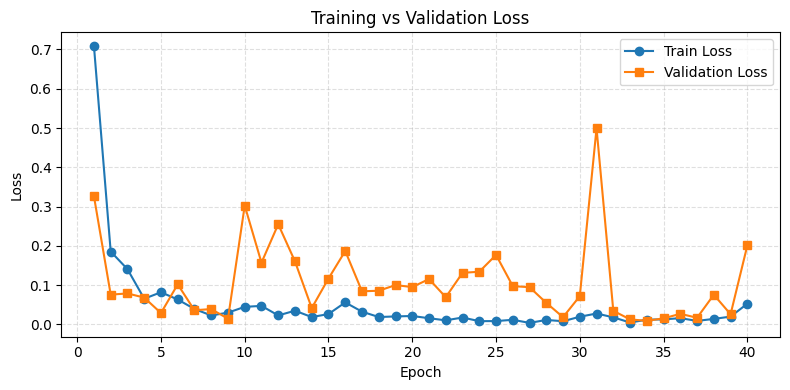

In [53]:
plot_training_history(history)

In [55]:
run_live_webcam_inference()

I0000 00:00:1763320845.554637  195994 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1763320845.558505  222245 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 24.2.8-1), renderer: Mesa Intel(R) Xe Graphics (TGL GT2)
W0000 00:00:1763320845.576212  222239 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763320845.606235  222241 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Usage Workflow

1. **Configure Paths**: Adjust `ARSLConfig.dataset_root` if your dataset lives elsewhere.
2. **Cache Landmarks**: Run `generate_all_caches(overwrite=True)` once to convert frame folders into landmark sequences.
3. **Train**: Execute `model = full_training_pipeline()` (or run preprocessing + `train_model` manually) to train and save the Temporal CNN.
4. **Evaluate/Infer**: Use `predict_instance(Path('/path/to/instance_folder'), model, label_map)` to classify a folder of frames.

Repeat preprocessing whenever you change `sequence_length`, add clips, or tweak MediaPipe settings.

5. **Live Webcam**: After training, call `run_live_webcam_inference()` locally to stream real-time predictions (press `q` to exit).

6. **Visualize**: Feed the `history` returned by `full_training_pipeline()` into `plot_training_history(history)` to inspect loss curves.
